# Causomic User Manual

**Causomic** performs causal inference on omics data. Its goal is to predict the effect of
*interventions* — for example, inhibiting a protein with a drug — on a biological system,
using observational data together with prior biological knowledge.

## The workflow

Causomic turns a data matrix and a (noisy) prior network into interventional predictions in
three steps:

1. **Inputs** — a `Gene × Run` matrix (one abundance value per protein per sample) and a
   **prior network** of candidate regulatory edges (e.g. pulled from INDRA).
2. **Learn a causal graph** — reconcile the noisy prior with the data, keeping only the edges
   the data support (`estimate_posterior_dag`).
3. **Train a structural causal model (SCM)** on the learned graph (`LVM`), then
   **predict interventions** — the downstream effect of perturbing a protein
   (`lvm.intervention`).

This first walkthrough uses **simulated data**, so it runs end-to-end with no external
database or credentials. Because we generate the ground-truth network ourselves, we can also
check Causomic's answers against the truth. A later section repeats the workflow on a real
INDRA network.

In [1]:
import warnings
import logging

# quiet the import-time noise from optional INDRA web/UI components
warnings.filterwarnings("ignore")
logging.getLogger("indra_cogex").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pyro
import torch

from causomic.simulation import (
    generate_structured_dag,
    generate_indra_data,
    simulate_data,
    ground_truth_interventional_effect,
)
from causomic.network import estimate_posterior_dag
from causomic.graph_construction.prior_data_reconciliation import (
    BICGaussIndraPriors,
    SparseHillClimb,
)
from causomic.causal_model.LVM import LVM

%matplotlib inline

SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

### A small plotting helper

We draw networks a few times below, coloring nodes by their role in the pathway (inputs,
mediators, readouts) and highlighting spurious proteins. This cell is only for visualization —
it is not part of Causomic, so feel free to skip over it.

In [2]:
ROLE_COLORS = {
    "start": "#4C9F70",      # inputs / ligands
    "mediator": "#9DB4C0",   # mediators
    "end": "#E8853A",        # readouts
    "confounder": "#8E7CC3",
    "spurious": "#D1495B",   # not part of the true network
}

def role_of(node, roles):
    if node in roles.get("start", []):        return "start"
    if node in roles.get("end", []):          return "end"
    if node in roles.get("confounders", []):  return "confounder"
    if node in roles.get("mediators", []):    return "mediator"
    return "spurious"

def layered_pos(G):
    # left-to-right layout by topological depth; falls back to spring layout
    try:
        pos = {}
        for x, layer in enumerate(nx.topological_generations(G)):
            for y, n in enumerate(sorted(layer)):
                pos[n] = (x, -(y - (len(layer) - 1) / 2))
        return pos
    except Exception:
        return nx.spring_layout(G, seed=SEED)

def draw_graph(G, roles, title, ax):
    pos = layered_pos(G)
    colors = [ROLE_COLORS[role_of(n, roles)] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#8a8a8a", arrows=True,
                           arrowsize=12, width=1.2, node_size=650)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=650,
                           edgecolors="white", linewidths=1.2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white")
    ax.set_title(title, fontsize=13)
    ax.axis("off")

## A simulated ground-truth system

In a real experiment you never know the true wiring of the cell — that is exactly what you are
trying to recover. To *evaluate* Causomic, we start from a known network and later check whether
we get it back.

`generate_structured_dag` builds a small signaling network with **inputs** (ligands, `L*`),
**mediators** (`M*`), and **readouts** (`R*`). We treat this as the ground truth and pretend we
do not know it.

inputs   : ['L0', 'L1', 'L2']
readouts : ['R0', 'R1']
mediators: ['M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6']


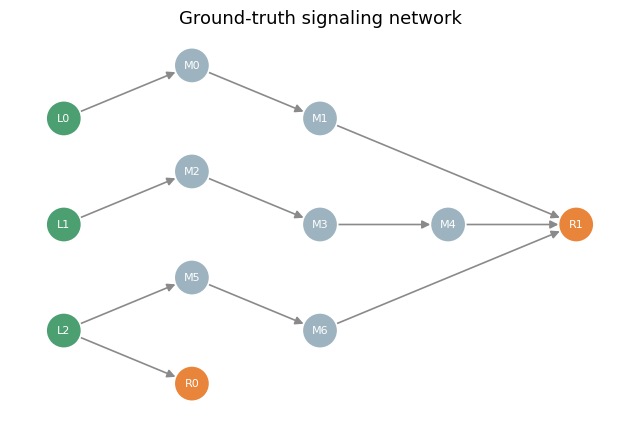

In [3]:
gt_dag, roles = generate_structured_dag(
    n_start=3,                # inputs / ligands
    n_end=2,                  # readouts
    max_mediators=2,          # mediator depth between inputs and readouts
    shared_mediator_prob=0.3, # cross-talk: mediators reused across pathways
    confounder_prob=0.0,      # keep it simple: no latent confounders here
    hub_prob=0.5,
    seed=SEED,
)

print("inputs   :", roles["start"])
print("readouts :", roles["end"])
print("mediators:", roles["mediators"])

fig, ax = plt.subplots(figsize=(8, 5))
draw_graph(gt_dag, roles, "Ground-truth signaling network", ax)
plt.show()

## A realistic (messy) prior network

Prior-knowledge bases like INDRA are noisy: they contain **spurious edges**, **irrelevant
proteins**, and sometimes **miss real edges**. Causomic is designed to work *with* this
messiness rather than assume a clean prior.

`generate_indra_data` corrupts the ground-truth graph into an INDRA-style prior. It adds
spurious proteins (`X*`) and spurious edges, and attaches a simulated literature
`evidence_count` to every edge (real edges tend to accumulate more evidence). This noisy prior
— **not** the ground truth — is what we hand to Causomic, as a `source → target` edge table.

In [4]:
n_nodes = gt_dag.number_of_nodes()
n_edges = gt_dag.number_of_edges()

indra_dag, indra_prior, _missing = generate_indra_data(
    gt_dag,
    num_incorrect_nodes=round(n_nodes * 1.0),   # add ~1 spurious protein per real one
    num_incorrect_edges=round(n_edges * 2.0),   # add ~2 spurious edges per real one
    preferential_attachment=True,               # spurious edges attach to hubs (realistic)
)

print(f"prior network: {indra_dag.number_of_nodes()} nodes, {len(indra_prior)} edges, "
      f"only {indra_prior['ground_truth'].mean():.0%} of edges are real")
indra_prior.head()

prior network: 24 nodes, 55 edges, only 20% of edges are real


,source,target,ground_truth,evidence_count
0,L0,M0,True,32
1,L0,M6,False,2
2,L0,R1,False,4
3,L0,M5,False,2
4,M0,M1,True,77


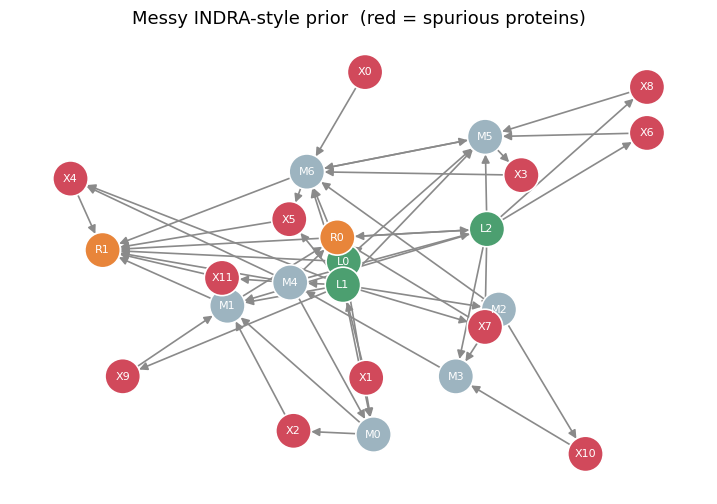

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
draw_graph(indra_dag, roles, "Messy INDRA-style prior  (red = spurious proteins)", ax)
plt.show()

## The data matrix

Causomic's other input is the measured data: a `Run × Protein` matrix — each row a sample (MS
run), each column a protein. `simulate_data` draws this from the ground-truth network via a
linear structural equation model. We include the spurious proteins as measured-but-unconnected
columns, exactly as they would appear in a real dataset.

In [6]:
# spurious proteins are measured too, but have no real regulatory edges
spurious = [n for n in indra_dag.nodes() if n not in gt_dag.nodes()]
augmented = gt_dag.copy()
augmented.add_nodes_from(spurious)

sim = simulate_data(augmented, n=600, add_feature_var=False, add_error=True,
                    seed=SEED, verbose=False)
protein_data = pd.DataFrame(sim["Protein_data"])

print("data matrix (runs x proteins):", protein_data.shape)
protein_data.iloc[:5, :8].round(2)

data matrix (runs x proteins): (600, 24)


,L0,L1,L2,X0,X1,X2,X3,X4
0,19.95,23.31,13.41,18.08,26.40,17.14,25.92,24.37
1,22.06,22.53,13.29,16.49,23.16,13.99,22.94,23.98
2,21.28,20.45,16.49,20.82,26.09,16.85,23.68,24.89
3,20.07,22.81,17.88,20.06,21.90,19.90,19.20,20.73
4,16.61,18.56,14.25,17.91,27.13,17.35,23.27,22.82


## Step 1 — Learn the causal graph

`estimate_posterior_dag` reconciles the noisy prior with the data. It runs **bootstrapped
structure learning** constrained to the prior's edges, scoring each candidate DAG with a
Gaussian BIC that is nudged by the prior evidence counts. Edges that recur across bootstrap
resamples (probability ≥ `edge_probability`) are kept; spurious edges and proteins that the data
do not support are dropped.

Because we know the ground truth here, we can score the result with **precision** and **recall**.
In a real analysis you would inspect the returned graph directly.

In [7]:
posterior, bootstrap_dags = estimate_posterior_dag(
    protein_data,
    indra_priors=indra_prior,
    prior_strength=5.0,
    scoring_function=BICGaussIndraPriors,
    search_algorithm=SparseHillClimb,
    n_bootstrap=50,
    edge_probability=0.5,
    return_bootstrap_dags=True,
    verbose=False,
)

# posterior is a y0 NxMixedGraph; pull its directed edges as plain strings
learned = nx.DiGraph([(str(u), str(v)) for u, v in posterior.directed.edges()])

predicted, truth = set(learned.edges()), set(gt_dag.edges())
tp = len(predicted & truth)
print(f"learned {len(predicted)} edges  |  "
      f"precision = {tp / len(predicted):.2f}   recall = {tp / len(truth):.2f}")

Hill Climb Bootstraps:   0%|          | 0/50 [00:00<?, ?it/s]

Hill Climb Bootstraps:  14%|█▍        | 7/50 [00:00<00:00, 60.75it/s]

Hill Climb Bootstraps:  28%|██▊       | 14/50 [00:05<00:16,  2.13it/s]

Hill Climb Bootstraps:  42%|████▏     | 21/50 [00:05<00:08,  3.58it/s]

Hill Climb Bootstraps:  56%|█████▌    | 28/50 [00:06<00:04,  5.43it/s]

Hill Climb Bootstraps:  70%|███████   | 35/50 [00:06<00:01,  7.64it/s]

Hill Climb Bootstraps:  84%|████████▍ | 42/50 [00:06<00:00, 10.24it/s]

Hill Climb Bootstraps:  98%|█████████▊| 49/50 [00:07<00:00, 12.66it/s]

Hill Climb Bootstraps: 100%|██████████| 50/50 [00:07<00:00,  7.11it/s]

learned 11 edges  |  precision = 0.91   recall = 0.91


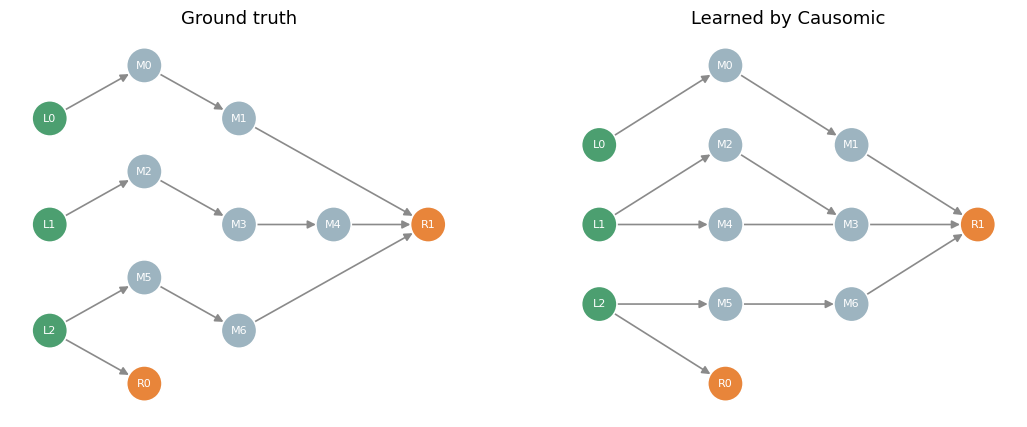

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_graph(gt_dag, roles, "Ground truth", axes[0])
draw_graph(learned, roles, "Learned by Causomic", axes[1])
plt.show()

## Step 2 — Train the structural causal model

With a graph in hand, we fit an `LVM` (latent variable model): a Bayesian SCM that learns a
structural equation for every node, can absorb latent confounders, and handles missing data.
`fit` takes the data matrix and the learned graph. Here we use the `pyro` backend with
stochastic variational inference.

In [9]:
pyro.clear_param_store()
lvm = LVM(backend="pyro", num_steps=1000, verbose=False)
lvm.fit(protein_data, posterior)

## Step 3 — Interventional inference

Now the payoff — a causal question the *observational* data cannot answer directly:
**if we inhibit input `L2`, what happens to the readouts?**

`lvm.intervention` applies the do-operator: it fixes `L2` to a knocked-down level, propagates the
effect through the SCM, and returns posterior samples of each readout at baseline
(`compare_value`) and under the intervention. The predicted effect is the difference of the two.
Since we know the true structural equations, we compare against the exact ground-truth effect.

In [10]:
target = "L2"
baseline_level = float(protein_data[target].mean())
knockdown_level = baseline_level - 8.0        # inhibit L2 well below its normal level

lvm.intervention(
    {target: knockdown_level},
    outcome_node=roles["end"],
    compare_value=baseline_level,
    predictive_samples=400,
)
predicted_effect = (lvm.intervention_samples - lvm.posterior_samples).mean()

# exact ground-truth effect for the same contrast, from the known SEM coefficients
gt_knock = ground_truth_interventional_effect(
    gt_dag, sim["Coefficients"], {target: knockdown_level}, roles["end"])["effect"]
gt_base = ground_truth_interventional_effect(
    gt_dag, sim["Coefficients"], {target: baseline_level}, roles["end"])["effect"]
truth_effect = {k: gt_knock[k] - gt_base[k] for k in roles["end"]}

pd.DataFrame({
    "predicted": predicted_effect,
    "ground_truth": pd.Series(truth_effect),
}).round(3)

,predicted,ground_truth
R0,-3.869,-5.304
R1,0.026,0.450


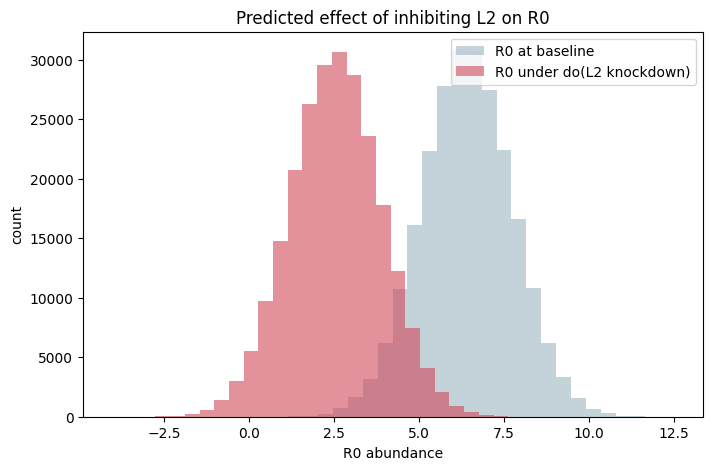

In [11]:
readout = "R0"   # the readout directly downstream of L2
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lvm.posterior_samples[readout], bins=30, alpha=0.6,
        color=ROLE_COLORS["mediator"], label=f"{readout} at baseline")
ax.hist(lvm.intervention_samples[readout], bins=30, alpha=0.6,
        color=ROLE_COLORS["spurious"], label=f"{readout} under do({target} knockdown)")
ax.set_xlabel(f"{readout} abundance")
ax.set_ylabel("count")
ax.set_title(f"Predicted effect of inhibiting {target} on {readout}")
ax.legend()
plt.show()

## Part 1 recap

Starting from a **noisy prior network** and a **data matrix**, Causomic:

1. **learned a causal graph** that recovered the ground-truth pathway, pruning the spurious
   proteins and edges;
2. **trained an SCM** on that graph; and
3. **predicted an interventional effect** — inhibiting `L2` lowers readout `R0` — that matches
   the ground-truth direction.

Every step used only the public `causomic` API; nothing here required external data or
credentials.

---

# Part 2 — A real INDRA network

Part 1 used a fully simulated system. Now we run the **same three steps** on a real regulatory
network pulled from **INDRA**, centered on the drug target **EGFR**.

Two things change, and one thing stays the same:

- **The prior is real.** Instead of `generate_indra_data`, the candidate edges come from INDRA:
  real genes (`EGFR`, `MAPK1`, `RAF1`, …), real literature `evidence_count`, and real-world
  messiness — redundant edges and feedback loops.
- **The data are still simulated.** No public proteomics dataset matches this exact gene set, so
  we simulate abundances from the network's canonical structure. That also gives us a ground
  truth to check the interventional predictions against.
- **The workflow is identical:** learn a graph → train an SCM → predict an intervention.

### Load the INDRA prior

In practice you pull the prior from INDRA with `extract_indra_prior` (or helpers like
`pull_downstream_network` / `query_forward_paths`), which return a `source → target` edge table
with a literature `evidence_count`. That query needs INDRA credentials, so here we load a small
saved EGFR subnetwork shipped with the package, keeping the notebook fully offline.

In [12]:
indra_prior = pd.read_csv("../data/indra/egfr_prior.csv")
genes = sorted(set(indra_prior["source"]) | set(indra_prior["target"]))
print(f"{len(indra_prior)} edges among {len(genes)} genes: {genes}")
indra_prior

16 edges among 9 genes: ['AKT1', 'EGFR', 'JUN', 'KRAS', 'MAP2K1', 'MAPK1', 'MAPK3', 'RAF1', 'SHC1']


,source,target,evidence_count,stmt_type
0,EGFR,AKT1,15,DecreaseAmount;IncreaseAmount
1,EGFR,JUN,11,IncreaseAmount
2,EGFR,KRAS,11,DecreaseAmount;IncreaseAmount
3,EGFR,MAPK1,15,DecreaseAmount;IncreaseAmount
4,EGFR,MAPK3,2,DecreaseAmount;IncreaseAmount
5,EGFR,RAF1,2,DecreaseAmount
6,EGFR,SHC1,1,IncreaseAmount
7,MAP2K1,EGFR,1,IncreaseAmount
8,MAP2K1,JUN,1,IncreaseAmount
9,MAP2K1,MAPK1,5,DecreaseAmount;IncreaseAmount


### Orient the network into a ground-truth DAG

Real INDRA networks are **cyclic** — here `RAF1 ⇄ MAP2K1` plus a `MAP2K1 → EGFR` feedback edge —
and a structural causal model needs a DAG. We orient the edges along the canonical EGFR signaling
direction (receptor → adaptors → RAS → RAF → MEK → ERK → transcription) and drop the few that
point backward. This oriented backbone is the ground truth we simulate from; the **full cyclic
prior** is still what we hand to the learner.

input   : ['EGFR']
readouts: ['SHC1', 'KRAS', 'MAPK1', 'MAPK3', 'AKT1', 'JUN']


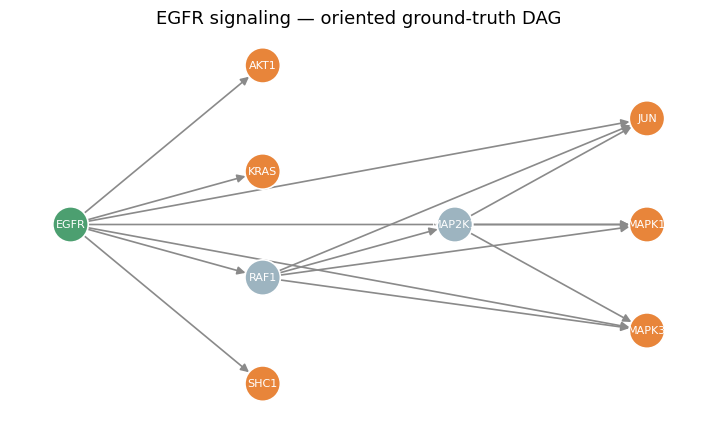

In [13]:
# canonical signaling tiers: receptor (0) -> ... -> transcriptional readout (5)
tier = {"EGFR": 0, "SHC1": 1, "KRAS": 1, "RAF1": 2, "MAP2K1": 3,
        "MAPK1": 4, "MAPK3": 4, "AKT1": 4, "JUN": 5}

gt_dag = nx.DiGraph()
gt_dag.add_nodes_from(tier)
for _, e in indra_prior.iterrows():
    if tier[e["source"]] < tier[e["target"]]:        # keep forward (downstream) edges only
        gt_dag.add_edge(e["source"], e["target"])

egfr_roles = {
    "start":       [n for n in gt_dag if gt_dag.in_degree(n) == 0],
    "end":         [n for n in gt_dag if gt_dag.out_degree(n) == 0],
    "mediators":   [n for n in gt_dag if gt_dag.in_degree(n) and gt_dag.out_degree(n)],
    "confounders": [],
}
print("input   :", egfr_roles["start"])
print("readouts:", egfr_roles["end"])

fig, ax = plt.subplots(figsize=(9, 5))
draw_graph(gt_dag, egfr_roles, "EGFR signaling — oriented ground-truth DAG", ax)
plt.show()

### Simulate a data matrix

As in Part 1, `simulate_data` draws a `Run × Protein` matrix from the ground-truth network.

In [14]:
np.random.seed(SEED)          # seed Part 2 independently so it is reproducible on its own
torch.manual_seed(SEED)

egfr_sim = simulate_data(gt_dag, n=600, add_feature_var=False, add_error=True,
                         seed=SEED, verbose=False)
egfr_data = pd.DataFrame(egfr_sim["Protein_data"])
print("data matrix (runs x proteins):", egfr_data.shape)
egfr_data.iloc[:5].round(2)

data matrix (runs x proteins): (600, 9)


,EGFR,AKT1,KRAS,RAF1,SHC1,MAP2K1,JUN,MAPK1,MAPK3
0,19.28,14.13,12.66,2.72,8.39,8.89,14.10,14.79,5.51
1,20.82,12.17,12.68,6.55,10.36,10.33,15.91,14.11,5.70
2,17.16,16.69,11.33,4.14,9.74,10.58,12.16,15.91,4.75
3,15.16,18.32,10.51,4.59,10.33,10.37,11.41,14.80,7.56
4,19.58,14.11,12.44,6.77,10.39,7.68,11.68,13.57,4.74


### Learn the graph and train the SCM

Identical to Part 1: hand the **messy real prior** and the data to `estimate_posterior_dag`, then
fit the `LVM`. The learner must return a DAG, so it naturally drops the prior's feedback edges. It
recovers the high-confidence backbone at high precision; a few redundant low-evidence edges — where
a readout is already driven *directly* by EGFR — are not separable from the data alone.

Hill Climb Bootstraps:   0%|          | 0/50 [00:00<?, ?it/s]

Hill Climb Bootstraps:  56%|█████▌    | 28/50 [00:00<00:00, 157.77it/s]

Hill Climb Bootstraps:  88%|████████▊ | 44/50 [00:00<00:00, 123.70it/s]

Hill Climb Bootstraps: 100%|██████████| 50/50 [00:00<00:00, 145.46it/s]

learned 10 edges  |  precision = 1.00   recall = 0.71


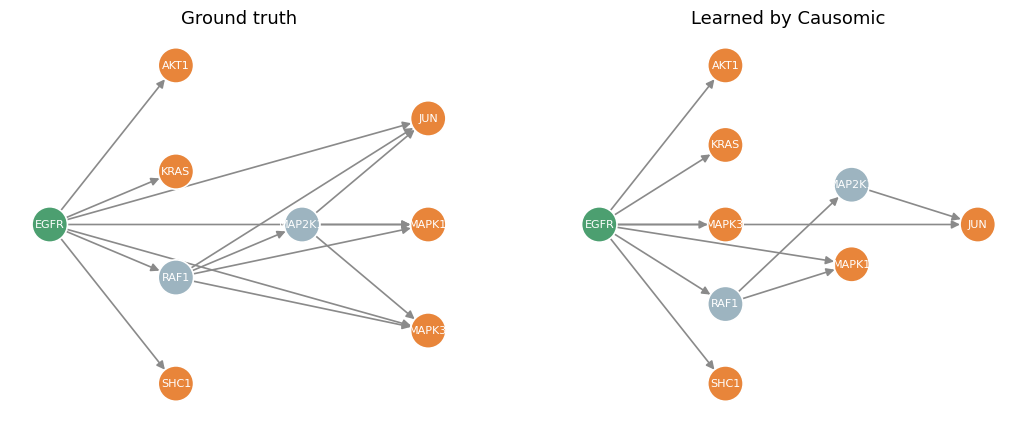

In [15]:
egfr_post, _ = estimate_posterior_dag(
    egfr_data,
    indra_priors=indra_prior,
    prior_strength=5.0,
    scoring_function=BICGaussIndraPriors,
    search_algorithm=SparseHillClimb,
    n_bootstrap=50,
    edge_probability=0.5,
    return_bootstrap_dags=True,
    verbose=False,
)

egfr_learned = nx.DiGraph([(str(u), str(v)) for u, v in egfr_post.directed.edges()])
predicted, truth = set(egfr_learned.edges()), set(gt_dag.edges())
tp = len(predicted & truth)
print(f"learned {len(predicted)} edges  |  "
      f"precision = {tp / len(predicted):.2f}   recall = {tp / len(truth):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_graph(gt_dag, egfr_roles, "Ground truth", axes[0])
draw_graph(egfr_learned, egfr_roles, "Learned by Causomic", axes[1])
plt.show()

In [16]:
pyro.clear_param_store()
egfr_lvm = LVM(backend="pyro", num_steps=1000, verbose=False)
egfr_lvm.fit(egfr_data, egfr_post)

### Predict an EGFR inhibition

The causal question: **inhibit EGFR — what happens downstream?** We knock EGFR down and read the
predicted effect on every terminal node, comparing against the exact ground-truth effect. (The
simulation gives each edge a random regulatory sign, so some readouts rise and some fall — the test
is whether the predictions *track the ground truth*.)

In [17]:
baseline_egfr = float(egfr_data["EGFR"].mean())

egfr_lvm.intervention(
    {"EGFR": baseline_egfr - 8.0},
    outcome_node=egfr_roles["end"],
    compare_value=baseline_egfr,
    predictive_samples=400,
)
predicted_effect = (egfr_lvm.intervention_samples - egfr_lvm.posterior_samples).mean()

hi = ground_truth_interventional_effect(
    gt_dag, egfr_sim["Coefficients"], {"EGFR": baseline_egfr - 8.0}, egfr_roles["end"])["effect"]
lo = ground_truth_interventional_effect(
    gt_dag, egfr_sim["Coefficients"], {"EGFR": baseline_egfr}, egfr_roles["end"])["effect"]
truth_effect = {k: hi[k] - lo[k] for k in egfr_roles["end"]}

pd.DataFrame({
    "predicted": predicted_effect,
    "ground_truth": pd.Series(truth_effect),
}).round(3)

,predicted,ground_truth
AKT1,3.306,3.711
JUN,-1.544,-1.582
KRAS,-1.985,-2.535
MAPK1,0.185,0.153
MAPK3,0.929,1.012
SHC1,1.741,2.194


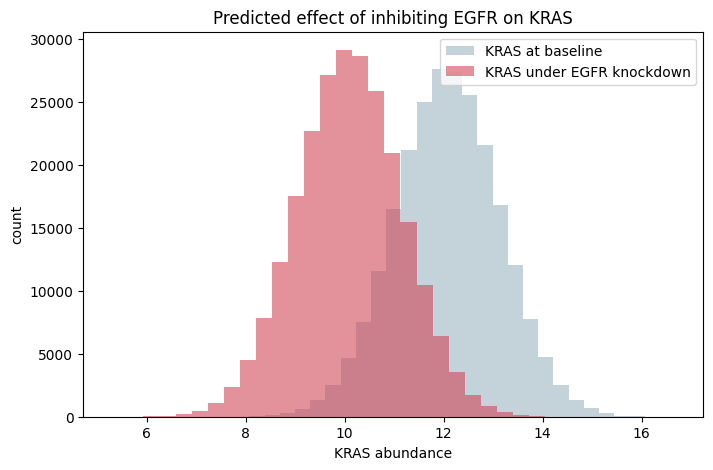

In [18]:
readout = "KRAS"   # a node directly downstream of EGFR that drops under knockdown
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(egfr_lvm.posterior_samples[readout], bins=30, alpha=0.6,
        color=ROLE_COLORS["mediator"], label=f"{readout} at baseline")
ax.hist(egfr_lvm.intervention_samples[readout], bins=30, alpha=0.6,
        color=ROLE_COLORS["spurious"], label=f"{readout} under EGFR knockdown")
ax.set_xlabel(f"{readout} abundance")
ax.set_ylabel("count")
ax.set_title(f"Predicted effect of inhibiting EGFR on {readout}")
ax.legend()
plt.show()

## Part 2 recap

On a **real INDRA network**, Causomic ran the same pipeline: it reconciled a cyclic, redundant
prior with the data into a coherent causal DAG (recovering the high-confidence backbone of the
oriented EGFR cascade), trained an SCM, and predicted the downstream effect of inhibiting EGFR —
matching the ground-truth direction across every readout.

The only thing that changed from Part 1 was the *source* of the prior. Swap in your own INDRA
pull and your own `Gene × Run` matrix and the same three steps apply.

> **On the data:** abundances here are simulated because no public proteomics dataset matches
> this gene set. With real measurements you would skip `simulate_data` and pass your processed
> matrix (e.g. the `ProteinLevelData` table from `MSstats::dataProcess`) straight to
> `estimate_posterior_dag`.